In [1]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize

import operator

warnings.filterwarnings('ignore') 

In [2]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [3]:
models = [
    'ACCESS-ESM1-5',
    'CESM2',
    'CNRM-CM6-1',
    'FGOALS-g3',
    'IPSL-CM6A-LR',
    'NESM3',
    'MIROC-ES2L', #starts with a lower siconc value than the control, so hits the paleo level in year 1. Exclude for now, but may want to investigate further.
    #'NorESM2-LM',  #issue with siconc data
]



transient = '1pctCO2'
control = 'piControl'
paleo = 'lig127k'

root_path = '/gws/nopw/j04/pmip4_vol1/public/matt/data/'

# energy_var_dict = {
#     'rsds': 1,
#     'rsus': -1,
#     'rlds': 1,
#     'rlus': -1,
#     'hfls': -1,
#     'hfss': -1
# }

energy_var_dict = {
    'rsds': 1,
    'rlds': 1,
}

energy_vars = list(energy_var_dict.keys())
ice_vars = ['siconc']#, 'sithick']
var_list = ice_vars + energy_vars

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [4]:
con = iris.Constraint(latitude=lambda lat: 60 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [5]:
def keep_full_years(cube, time_coord_name='time'):
    """
    Return a cube containing only complete calendar years:
    exactly one of each month Jan..Dec.

    Parameters
    ----------
    cube : iris.cube.Cube
        Input cube with a time coordinate.
    time_coord_name : str, optional
        Name of the time coordinate.

    Returns
    -------
    iris.cube.Cube
        Cube containing only full years.
    """
    time_coord = cube.coord(time_coord_name)
    datetimes = time_coord.units.num2date(time_coord.points)

    years = np.array([dt.year for dt in datetimes])
    months = np.array([dt.month for dt in datetimes])

    full_years = []

    for year in np.unique(years):
        year_months = months[years == year]

        # Require exactly 12 points and exactly months 1..12
        if len(year_months) == 12 and np.array_equal(np.sort(year_months), np.arange(1, 13)):
            full_years.append(year)

    full_years = np.array(full_years)

    if len(full_years) == 0:
        raise ValueError("No complete years found in cube.")

    mask = np.isin(years, full_years)

    return cube[mask]

In [6]:

def get_cube_dict(model, experiment, var_list, root_path, con, shape):
    cube_dict = {}
    print(f'Loading cubes', end='...')
    for var in var_list:
        print(f'{var}', end='...')
        path = create_path(model, experiment, var, root_path)
        cube = get_cube(path, var, con, shape=shape)
        #need to trim incomplete years from start and end
        #trimmed_cube = keep_full_years(cube)
        #cube_dict[var] = trimmed_cube
        cube_dict[var] = cube
    print('Done.')
    return cube_dict

In [7]:

def get_ts_dict_from_cube_dict(cube_dict, var_list, energy_var_dict):
    ts_dict = {}
    energy_vars = list(energy_var_dict.keys())
    print(f'Calculating time series for', end='...')
    for var in var_list:
        print(f'{var}', end='...')


        cube = cube_dict[var]
        if var == 'siconc':
            analysis = 'sum'
        else:        
            analysis = 'mean'
        if var in energy_vars:
            multiplier = energy_var_dict[var]
        else:
            multiplier = 1

        area_weights = iris.analysis.cartography.area_weights(cube)
        op = get_iris_op(analysis)

        timeseries = (cube.collapsed(['latitude', 'longitude'], op, weights=area_weights)) * multiplier

        ts_dict[var] = timeseries

    print('Done.')
    return ts_dict


In [8]:
def get_clim_dict_from_ts_dict(ts_dict):

    var_list = list(ts_dict.keys())

    clim_dict = {}
    print(f'Calculating climatology for',end="...")
    for var in var_list:
        print(f'{var}',end="...")

        timeseries = ts_dict[var]

        analysis = 'mean'

        op = get_iris_op(analysis)

        clim = timeseries.aggregated_by('month', op)

        clim_dict[var] = clim

    print('Done.')
    return clim_dict

In [9]:
def calculate_anomalies(experiment_ts_dict, control_clim_dict = None):    
    experiment_anom_ts_dict = {}
    print(f'Calculating anomalies for', end='...')
    for var, ts in experiment_ts_dict.items():
        print(f'{var}',end="...")
        if control_clim_dict is None:
            #take first 10 years as control climatology
            clim = ts[:120].aggregated_by('month', iris.analysis.MEAN)
        else:
            clim = control_clim_dict[var]
        clim_data = clim.data
        ts_months = ts.coord("month_number").points
        
        month_index = ts_months.astype(int) - 1

        anomalies = ts.copy()
        anomalies.data = ts.data - clim_data[month_index]

        experiment_anom_ts_dict[var] = anomalies
    print('Done.')
    return experiment_anom_ts_dict

In [10]:
def get_annual_function(cube, op = 'sum'):
    

    #consider looking at weighting each two month block for importance
    #AprMay, #JunJul, #AugSep
    
    # Mask non-positive values
    #masked = cube.copy()
    #masked.data = np.ma.masked_less_equal(masked.data, 0)

    masked = cube.extract(iris.Constraint(month=lambda m: m in ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']))
    iris_analysis_op = get_iris_op(op)

    # Then aggregate by year using SUM
    sum_positive = masked.aggregated_by('year', iris_analysis_op)
    return sum_positive

    # Then aggregate by year using MEAN
    #mean_positive = masked.aggregated_by('year', iris.analysis.MEAN)
    #return mean_positive

In [11]:


transient_stats_dict = {}
paleo_predict_dict = {}
regression_method = 'linear_sum' #options: 'linear', 'ridge', 'linear_sum'
op = 'sum'

control_big_dict = {}
paleo_big_dict = {}
transient_big_dict = {}

for model in models:
  print(f'------------------Processing {model} {control}------------------')
  control_cube_dict = get_cube_dict(model, control, var_list, root_path, con, shape)
  control_ts_dict = get_ts_dict_from_cube_dict(control_cube_dict, var_list, energy_var_dict)
  control_clim_dict = get_clim_dict_from_ts_dict(control_ts_dict)

  control_big_dict[model] = {'cubes': control_cube_dict, 'ts': control_ts_dict, 'clim': control_clim_dict}

  print(f'------------------Processing {model} {transient}------------------')
  transient_cube_dict = get_cube_dict(model, transient, var_list, root_path, con, shape)
  transient_ts_dict = get_ts_dict_from_cube_dict(transient_cube_dict, var_list, energy_var_dict)
  transient_clim_dict = get_clim_dict_from_ts_dict(transient_ts_dict)


  transient_anom_ts_dict = calculate_anomalies(transient_ts_dict , control_clim_dict) 
      
  transient_anom_clim_dict = get_clim_dict_from_ts_dict(transient_anom_ts_dict)

  transient_big_dict[model] = {'cubes': transient_cube_dict, 
                               'ts': transient_ts_dict, 
                               'clim': transient_clim_dict,
                               'anom_ts': transient_anom_ts_dict,
                               'anom_clim': transient_anom_clim_dict,
                               }
  
  

  print(f'------------------Processing {model} {paleo}------------------')
  paleo_cube_dict = get_cube_dict(model, paleo, var_list, root_path, con, shape)
  paleo_ts_dict = get_ts_dict_from_cube_dict(paleo_cube_dict, var_list, energy_var_dict)
  paleo_clim_dict = get_clim_dict_from_ts_dict(paleo_ts_dict)
  paleo_anom_ts_dict = calculate_anomalies(paleo_ts_dict, control_clim_dict)
  paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)

  paleo_big_dict[model] = {'cubes': paleo_cube_dict, 
                           'ts': paleo_ts_dict, 
                           'clim': paleo_clim_dict,
                           'anom_ts': paleo_anom_ts_dict,
                           'anom_clim': paleo_anom_clim_dict,
                           }



------------------Processing ACCESS-ESM1-5 piControl------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing ACCESS-ESM1-5 1pctCO2------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating anomalies for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing ACCESS-ESM1-5 lig127k------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating anomalies for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing CESM2 piControl------------------
Loading

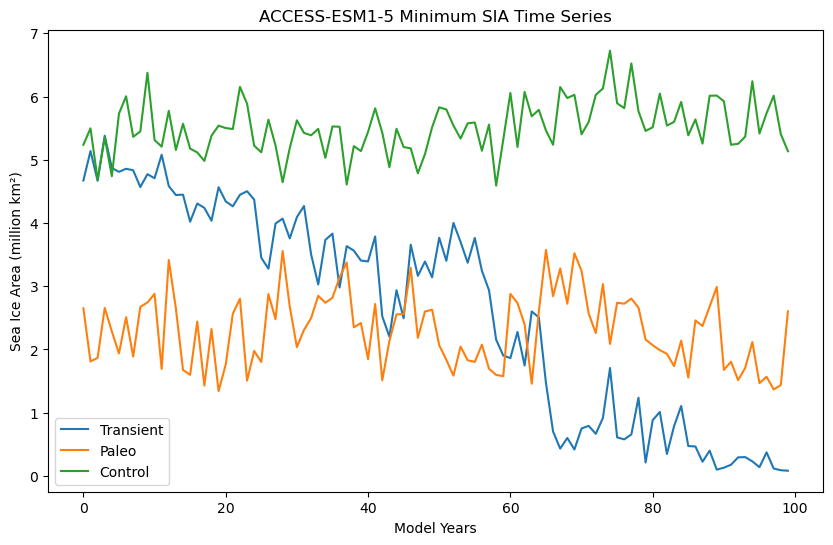

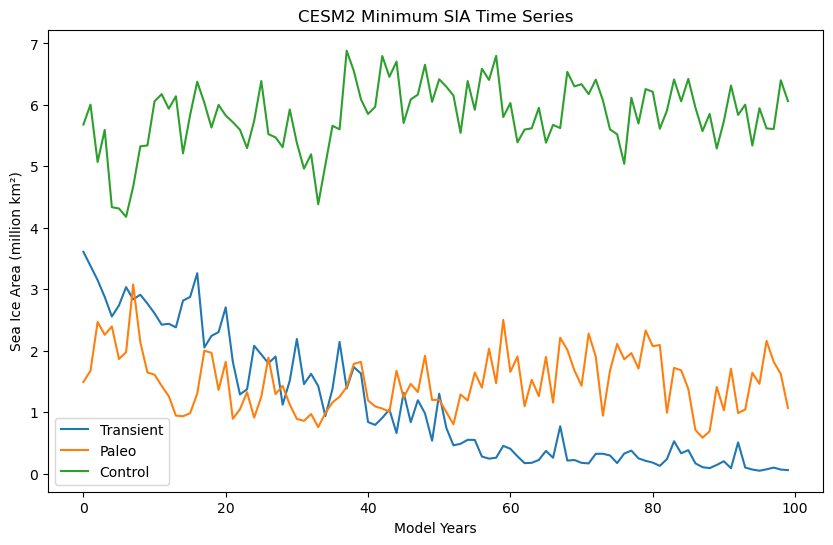

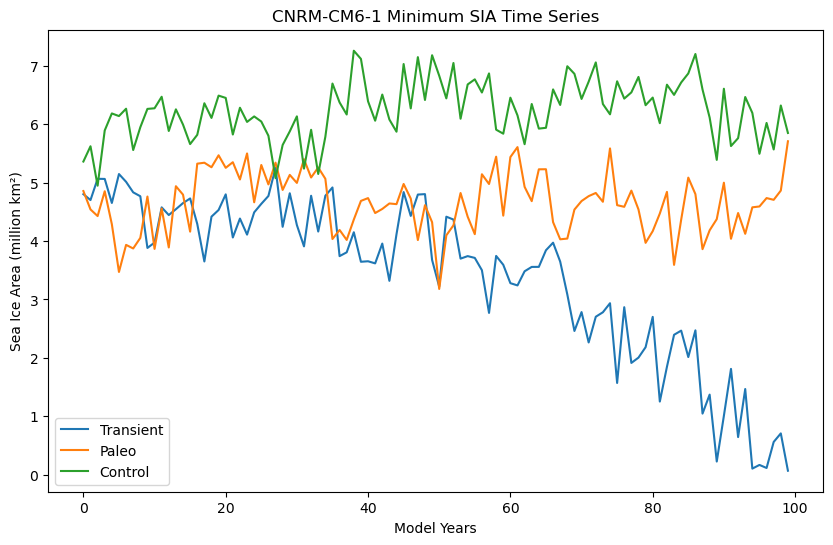

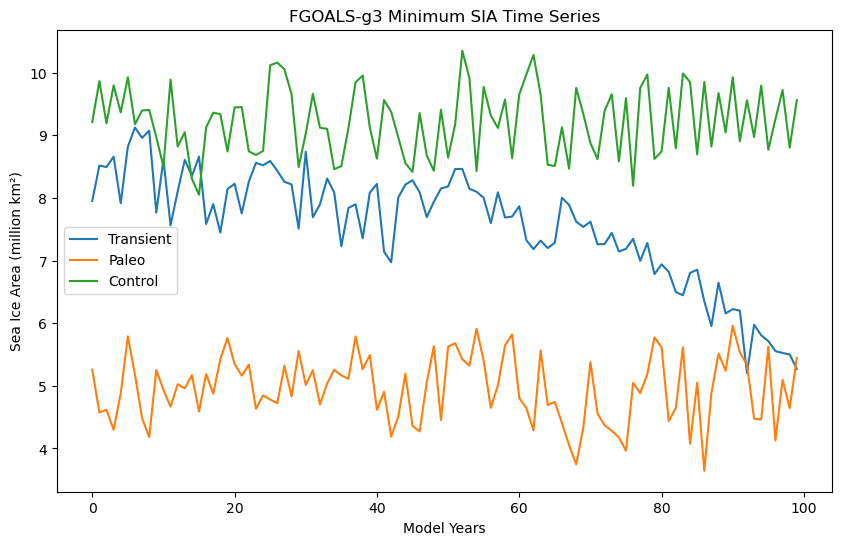

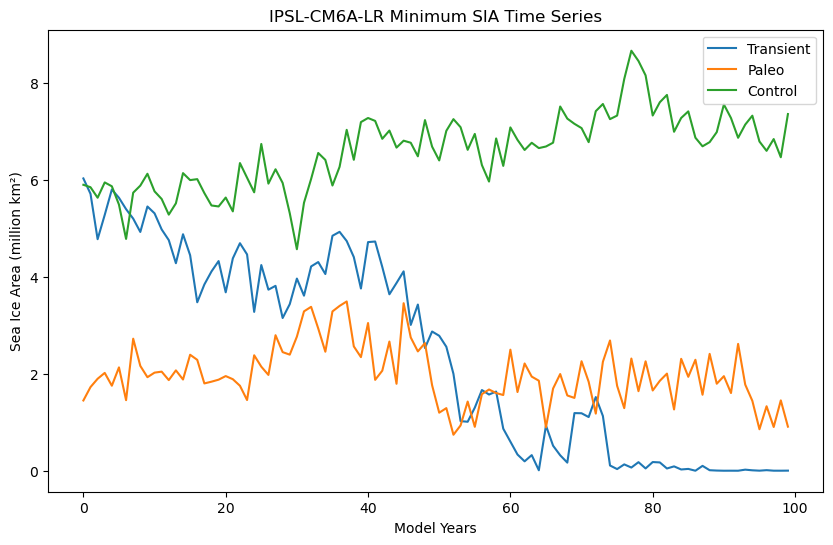

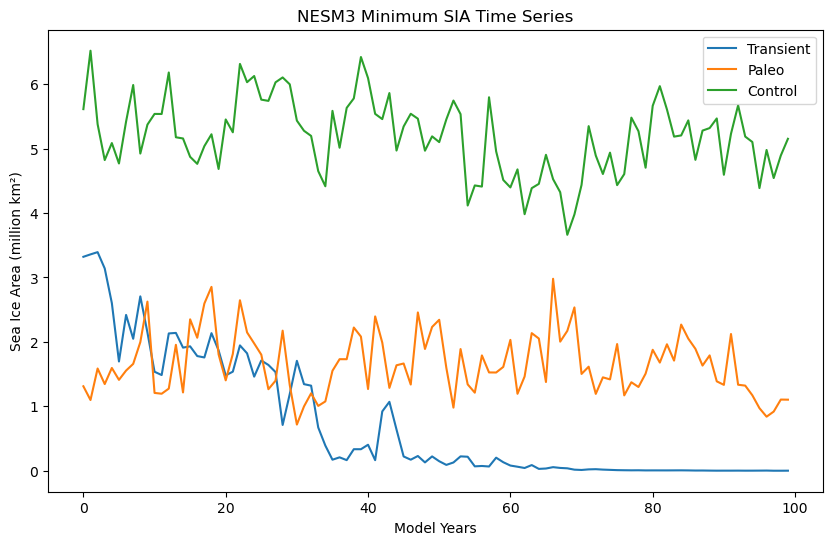

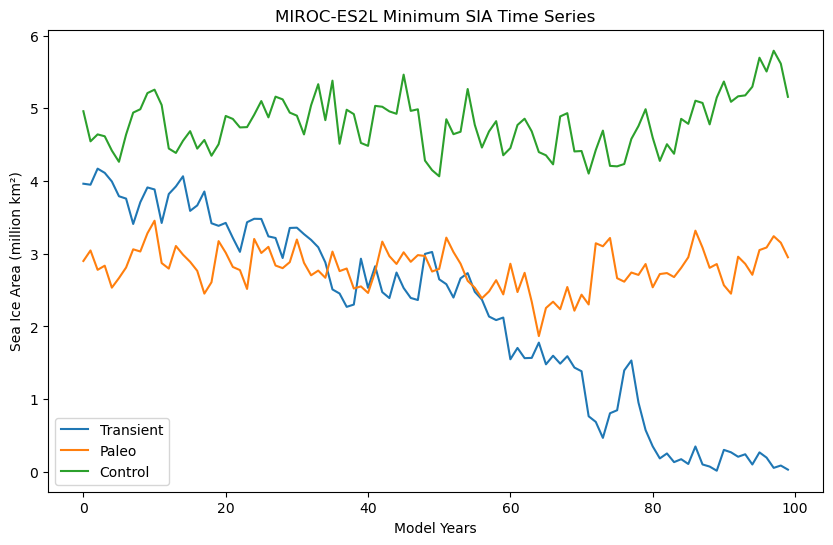

In [12]:
#better plots
for model in models:
    plt.figure(figsize=(10,6))
    plt.title(f'{model} Minimum SIA Time Series')
    plt.plot(transient_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month='Sep')).data[0:100]/1e14, label='Transient')
    plt.plot(paleo_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month='Aug')).data[0:100]/1e14, label='Paleo')
    plt.plot(control_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month='Sep')).data[0:100]/1e14, label='Control')
    plt.xlabel('Model Years')
    plt.ylabel('Sea Ice Area (million km²)')
    plt.legend()
    plt.show()

In [13]:
#for paleo, get sep siconc anomaly
window=10

crossing_big_dict = {}
for model in models:
    paleo_siconc_anom = paleo_big_dict[model]['anom_ts']['siconc'].extract(iris.Constraint(month='Aug')).collapsed('year', iris.analysis.MEAN) / 1e14
    
    transient_siconc_ts_anom = transient_big_dict[model]['anom_ts']['siconc'].extract(iris.Constraint(month='Sep')) / 1e14
    transient_min =  transient_siconc_ts_anom.data

    transient_min_rolling = pd.Series(transient_min).rolling(window=window, center=True).mean()

    n_years = transient_min_rolling.shape[0]
    years = np.arange(n_years) + 1
    sia_crossing_year = years[transient_min_rolling <= paleo_siconc_anom.data][0]

    print(f'{model} paleo Aug siconc anomaly: {paleo_siconc_anom.data:.2f}, transient crossing year: {sia_crossing_year}')
    crossing_var_dict = {}

    for var in var_list:
        cube = transient_big_dict[model]['anom_ts'][var]
        unique_years = np.unique(cube.coord('year').points)
        crossing_year_value = unique_years[sia_crossing_year - 1]
        crossing_clim = cube.extract(iris.Constraint(year= lambda y:  crossing_year_value - (window/2) < y <= crossing_year_value + (window/2))).aggregated_by('month', iris.analysis.MEAN)
        crossing_var_dict[var] = crossing_clim
    crossing_big_dict[model] = crossing_var_dict
    

ACCESS-ESM1-5 paleo Aug siconc anomaly: -3.47, transient crossing year: 64
CESM2 paleo Aug siconc anomaly: -4.49, transient crossing year: 45
CNRM-CM6-1 paleo Aug siconc anomaly: -1.69, transient crossing year: 36
FGOALS-g3 paleo Aug siconc anomaly: -3.42, transient crossing year: 96
IPSL-CM6A-LR paleo Aug siconc anomaly: -3.88, transient crossing year: 51
NESM3 paleo Aug siconc anomaly: -3.93, transient crossing year: 29
MIROC-ES2L paleo Aug siconc anomaly: -1.47, transient crossing year: 23


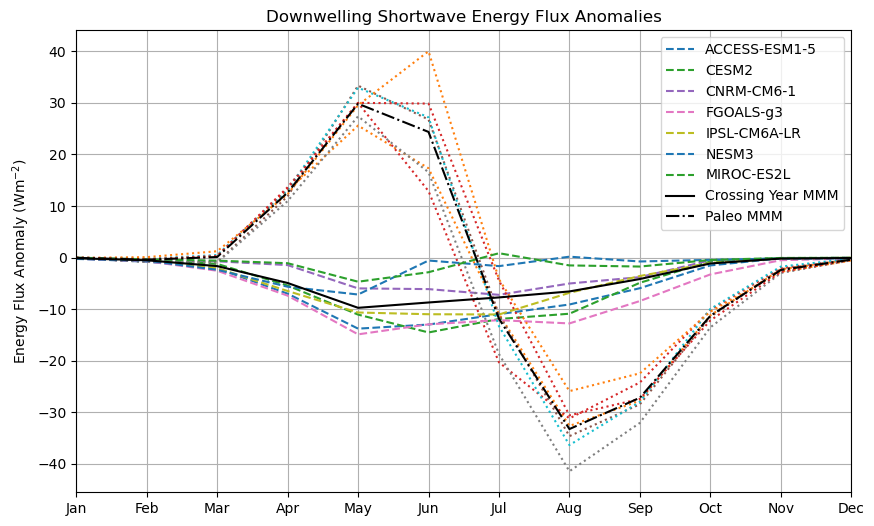

In [14]:
rsds_mmm_crossing = np.zeros(12)
rsds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['rsds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data 
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rsds_mmm_crossing += crossing_energy
    rsds_mmm_paleo += paleo_energy
rsds_mmm_crossing /= len(models)
rsds_mmm_paleo /= len(models)
plt.plot(rsds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rsds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Shortwave Energy Flux Anomalies')
plt.legend()
plt.show()

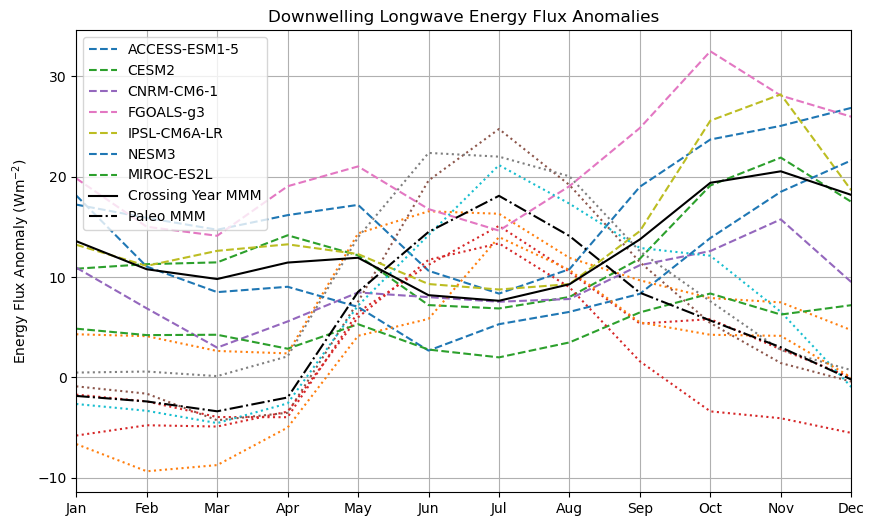

In [15]:
rlds_mmm_crossing = np.zeros(12)
rlds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rlds_mmm_crossing += crossing_energy
    rlds_mmm_paleo += paleo_energy
rlds_mmm_crossing /= len(models)
rlds_mmm_paleo /= len(models)
plt.plot(rlds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rlds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Longwave Energy Flux Anomalies')
plt.legend()
plt.show()

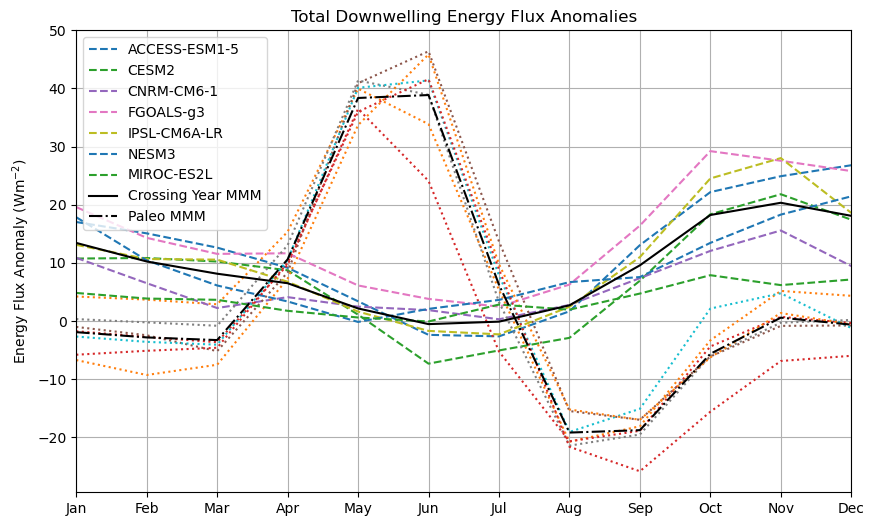

In [16]:

total_mmm_crossing = np.zeros(12)
total_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['rsds'].data + crossing_big_dict[model]['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data + paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    total_mmm_crossing += crossing_energy
    total_mmm_paleo += paleo_energy
total_mmm_crossing /= len(models)
total_mmm_paleo /= len(models)
plt.plot(total_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(total_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Total Downwelling Energy Flux Anomalies')
plt.legend()
plt.show()

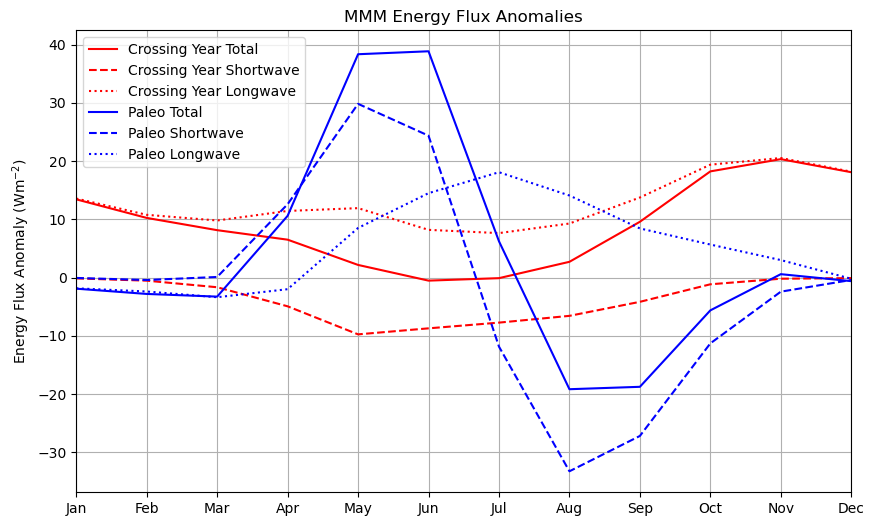

In [17]:
plt.figure(figsize=(10,6))
plt.plot(total_mmm_crossing, label='Crossing Year Total', color='red', linestyle='-')
plt.plot(rsds_mmm_crossing, label='Crossing Year Shortwave', color='red', linestyle='--')
plt.plot(rlds_mmm_crossing, label='Crossing Year Longwave', color='red', linestyle=':')

plt.plot(total_mmm_paleo, label='Paleo Total', color='blue', linestyle='-')
plt.plot(rsds_mmm_paleo, label='Paleo Shortwave', color='blue', linestyle='--')
plt.plot(rlds_mmm_paleo, label='Paleo Longwave', color='blue', linestyle=':')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'MMM Energy Flux Anomalies')
plt.legend()
plt.show()

In [18]:

def skewed_gaussian_month_weights(mu, sigma, skew):
    """
    Circular Gaussian month weights with a smooth circular skew term.

    Parameters
    ----------
    mu : float
        Peak month (1..12)
    sigma : float
        Width (>0)
    skew : float
        Asymmetry parameter.
        0 = symmetric
        >0 biases weights toward later months
        <0 biases weights toward earlier months
    """
    if sigma <= 0:
        return None

    months = np.arange(1, 13)

    # signed circular month difference in [-6, 6)
    d = (months - mu + 6) % 12 - 6

    # symmetric circular Gaussian envelope
    g = np.exp(-0.5 * (d / sigma) ** 2)

    # smooth skew term using angle around the circle
    theta = 2 * np.pi * d / 12.0
    s = np.exp(skew * np.sin(theta))

    w = g * s
    w = w / w.sum()
    return w


def calculate_model_energies(weights, models, crossing_big_dict, paleo_big_dict, rsds_weight = 1.0):
    """
    Calculate weighted crossing and paleo energies for each model.
    """
    crossing_vals = []
    paleo_vals = []
    model_names = []
    
    for model in models:
        crossing_rsds_clim = np.asarray(crossing_big_dict[model]['rsds'].data) * rsds_weight
        paleo_rsds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rsds'].data) * rsds_weight
        crossing_rlds_clim = np.asarray(crossing_big_dict[model]['rlds'].data)
        paleo_rlds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rlds'].data)

        # Check that each is monthly climatology of length 12
        for arr_name, arr in [
            ('crossing_rsds_clim', crossing_rsds_clim),
            ('paleo_rsds_clim', paleo_rsds_clim),
            ('crossing_rlds_clim', crossing_rlds_clim),
            ('paleo_rlds_clim', paleo_rlds_clim),
        ]:
            if arr.shape != (12,):
                raise ValueError(f"{model}: {arr_name} has shape {arr.shape}, expected (12,)")

        crossing_energy = np.dot(weights, crossing_rsds_clim + crossing_rlds_clim)
        paleo_energy = np.dot(weights, paleo_rsds_clim + paleo_rlds_clim)

        crossing_vals.append(crossing_energy)
        paleo_vals.append(paleo_energy)
        model_names.append(model)

    return np.asarray(crossing_vals), np.asarray(paleo_vals), model_names


def objective_mu_sigma_skew(params, models, crossing_big_dict, paleo_big_dict):
    """
    Objective function: minimise RMSE between crossing and paleo weighted energies
    across models.
    """
    mu, sigma, skew, rsds_weight = params

    # Basic guards
    if sigma <= 0:
        return np.inf

    weights = skewed_gaussian_month_weights(mu, sigma, skew)
    if weights is None:
        return np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict, rsds_weight=rsds_weight
    )

    rmse = np.sqrt(np.mean((crossing_vals - paleo_vals) ** 2))
    return rmse


def fit_skewed_month_weights(models, crossing_big_dict, paleo_big_dict,
                             mu0=6.0, sigma0=4.0, skew0=0.0, rsds_weight0=1.0):
    """
    Fit mu, sigma, and skew for skewed circular Gaussian month weights.

    Returns
    -------
    result : dict
        Dictionary containing best-fit parameters, weights, and diagnostics.
    """
    res = minimize(
        objective_mu_sigma_skew,
        x0=[mu0, sigma0, skew0, rsds_weight0],
        args=(models, crossing_big_dict, paleo_big_dict),
        bounds=[
            (1.0, 12.0),   # mu
            (0.2, 12.0),   # sigma
            (-0.95, 0.95),  # skew
            (0.5, 2.0)      # rsds_weight
        ],
        method='L-BFGS-B'
    )

    mu_opt, sigma_opt, skew_opt, rsds_weight_opt = res.x
    weights_opt = skewed_gaussian_month_weights(mu_opt, sigma_opt, skew_opt)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights_opt, models, crossing_big_dict, paleo_big_dict, rsds_weight=rsds_weight_opt
    )

    rmse = np.sqrt(np.mean((crossing_vals - paleo_vals) ** 2))

    # Regression diagnostics as extra information
    A = np.column_stack([crossing_vals, np.ones_like(crossing_vals)])
    slope, intercept = np.linalg.lstsq(A, paleo_vals, rcond=None)[0]
    paleo_pred = slope * crossing_vals + intercept

    ss_res = np.sum((paleo_vals - paleo_pred) ** 2)
    ss_tot = np.sum((paleo_vals - np.mean(paleo_vals)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        'success': res.success,
        'message': res.message,
        'mu': mu_opt,
        'sigma': sigma_opt,
        'skew': skew_opt,
        'weights': weights_opt,
        'rsds_weight': rsds_weight_opt,
        'crossing_vals': crossing_vals,
        'paleo_vals': paleo_vals,
        'model_names': model_names,
        'rmse_1to1': rmse,
        'regression_slope': slope,
        'regression_intercept': intercept,
        'regression_r2': r2,
        'optimizer_result': res,
    }


def plot_fitted_weights(result):
    """
    Plot the fitted monthly weights.
    """
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    plt.figure(figsize=(8, 4))
    plt.plot(month_labels, result['weights'], marker='o')
    plt.xlabel('Month')
    plt.ylabel('Weight')
    plt.title(
        f"Fitted weights: mu={result['mu']:.2f}, "
        f"sigma={result['sigma']:.2f}, skew={result['skew']:.2f}"
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_crossing_vs_paleo(result):
    """
    Plot weighted crossing energy vs weighted paleo energy.
    """
    x = result['crossing_vals']
    y = result['paleo_vals']
    names = result['model_names']

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y)

    for name, xi, yi in zip(names, x, y):
        plt.annotate(name, (xi, yi), textcoords='offset points', xytext=(5, 5), ha='left')

    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))

    # 1:1 line
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', label='1:1 line')

    # Best-fit regression line
    slope = result['regression_slope']
    intercept = result['regression_intercept']
    xline = np.array([min_val, max_val])
    yline = slope * xline + intercept
    plt.plot(xline, yline, '-', label=f'Fit: y={slope:.2f}x + {intercept:.2f}')

    plt.xlabel('Crossing weighted energy')
    plt.ylabel('Paleo weighted energy')
    plt.title(
        f"RMSE to 1:1 = {result['rmse_1to1']:.3f}, "
        f"R² = {result['regression_r2']:.3f}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Best-fit mu   : 4.984939692401864
Best-fit sigma: 5.2682341472621985
Best-fit skew : -0.95
Best-fit weights:
[0.1404081  0.18012364 0.17280426 0.12840731 0.0811818  0.04960797
 0.03326786 0.02685486 0.02697243 0.03254392 0.04322335 0.08460449]
Best-fit rsds_weight: 2.0
RMSE to 1:1 line: 2.0928866116722724
Regression slope: 0.3978422945662956
Regression intercept: 4.069785494286793
Regression R^2: 0.2720272893580592


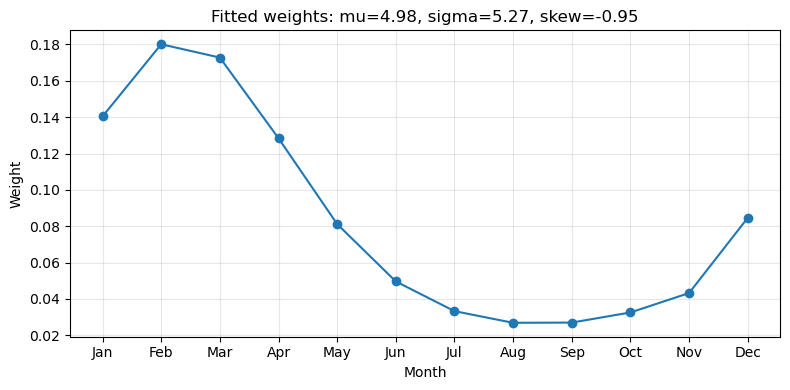

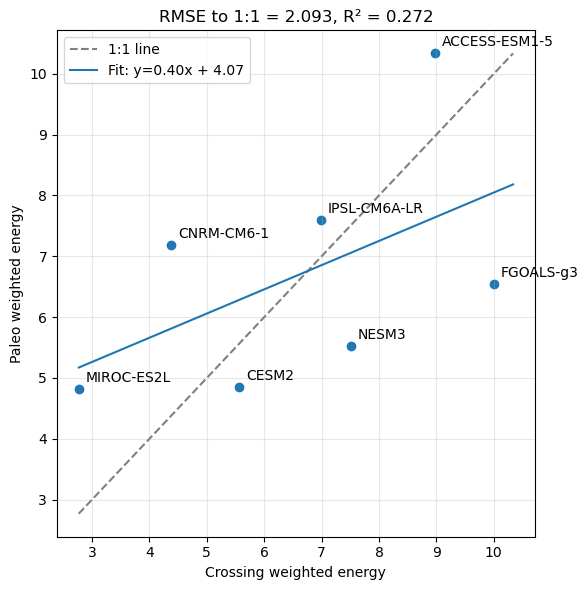

In [19]:

# -------------------------
# Run the fit
# -------------------------

result = fit_skewed_month_weights(
    models,
    crossing_big_dict,
    paleo_big_dict,
    mu0=6.0,
    sigma0=4.0,
    skew0=0.0
)

print("Success:", result['success'])
print("Message:", result['message'])
print("Best-fit mu   :", result['mu'])
print("Best-fit sigma:", result['sigma'])
print("Best-fit skew :", result['skew'])
print("Best-fit weights:")
print(result['weights'])
print("Best-fit rsds_weight:", result['rsds_weight'])
print("RMSE to 1:1 line:", result['rmse_1to1'])
print("Regression slope:", result['regression_slope'])
print("Regression intercept:", result['regression_intercept'])
print("Regression R^2:", result['regression_r2'])

plot_fitted_weights(result)
plot_crossing_vs_paleo(result)




In [20]:
weights = result['weights']
for model in models:
    print(model)
    sia = crossing_big_dict[model]['siconc'].extract(iris.Constraint(month='Sep')).data/1e14
    print(f'SIA at crossing: {sia:.2f}')
    weighted_energy = np.dot(weights, crossing_big_dict[model]['rsds'].data + crossing_big_dict[model]['rlds'].data)
    print(f'Weighted energy at crossing: {weighted_energy:.3f}')

    model_factor = sia / weighted_energy
    print(f'Model factor (SIA / weighted energy): {model_factor:.3f}')
    print(50*'-')

ACCESS-ESM1-5
SIA at crossing: -3.85
Weighted energy at crossing: 13.002
Model factor (SIA / weighted energy): -0.296
--------------------------------------------------
CESM2
SIA at crossing: -4.63
Weighted energy at crossing: 9.036
Model factor (SIA / weighted energy): -0.512
--------------------------------------------------
CNRM-CM6-1
SIA at crossing: -1.85
Weighted energy at crossing: 6.061
Model factor (SIA / weighted energy): -0.305
--------------------------------------------------
FGOALS-g3
SIA at crossing: -3.63
Weighted energy at crossing: 14.528
Model factor (SIA / weighted energy): -0.250
--------------------------------------------------
IPSL-CM6A-LR
SIA at crossing: -4.33
Weighted energy at crossing: 10.375
Model factor (SIA / weighted energy): -0.417
--------------------------------------------------
NESM3
SIA at crossing: -4.06
Weighted energy at crossing: 9.519
Model factor (SIA / weighted energy): -0.427
--------------------------------------------------
MIROC-ES2L
SI

In [21]:


def log_prior(mu, sigma, skew, log_obs_sigma):
    if not (1.0 <= mu <= 12.0):
        return -np.inf
    if not (0.2 <= sigma <= 12.0):
        return -np.inf
    if not (-2.0 <= skew <= 2.0):
        return -np.inf
    if not (-7.0 <= log_obs_sigma <= 5.0):
        return -np.inf

    lp_skew = -0.5 * (skew / 0.75) ** 2
    lp_sigma = -0.5 * ((sigma - 3.0) / 3.0) ** 2

    # Prior on obs_sigma: centred around 0.25, with moderate spread in log space
    lp_log_obs_sigma = -0.5 * ((log_obs_sigma - np.log(0.25)) / 0.5) ** 2

    return lp_skew + lp_sigma + lp_log_obs_sigma


def log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict):
    obs_sigma = np.exp(log_obs_sigma)

    weights = skewed_gaussian_month_weights(mu, sigma, skew)
    if weights is None:
        return -np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    diff = paleo_vals - crossing_vals
    n = diff.size

    ll = -0.5 * np.sum((diff / obs_sigma) ** 2) - n * np.log(obs_sigma) - 0.5 * n * np.log(2 * np.pi)
    return ll


def log_posterior(params, models, crossing_big_dict, paleo_big_dict):
    mu, sigma, skew, log_obs_sigma = params

    lp = log_prior(mu, sigma, skew, log_obs_sigma)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


def run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.0),  # last entry is log_obs_sigma
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.05, 0.08),
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    chain = np.zeros((n_steps, 4))
    logpost = np.zeros(n_steps)

    current = np.array(start, dtype=float)
    current_lp = log_posterior(current, models, crossing_big_dict, paleo_big_dict)

    if not np.isfinite(current_lp):
        raise ValueError("Initial parameter set has non-finite posterior.")

    chain[0] = current
    logpost[0] = current_lp

    n_accept = 0

    for i in range(1, n_steps):
        proposal = current + rng.normal(0.0, proposal_scales, size=4)
        proposal_lp = log_posterior(proposal, models, crossing_big_dict, paleo_big_dict)

        log_alpha = proposal_lp - current_lp

        if np.log(rng.uniform()) < log_alpha:
            current = proposal
            current_lp = proposal_lp
            n_accept += 1

        chain[i] = current
        logpost[i] = current_lp

    accept_rate = n_accept / (n_steps - 1)
    return chain, logpost, accept_rate

def summarise_posterior(chain, burn=5000, thin=10):
    """
    Return posterior samples after burn-in and thinning.
    """
    samples = chain[burn::thin]
    summary = {
        "mu_mean": np.mean(samples[:, 0]),
        "mu_std": np.std(samples[:, 0]),
        "sigma_mean": np.mean(samples[:, 1]),
        "sigma_std": np.std(samples[:, 1]),
        "skew_mean": np.mean(samples[:, 2]),
        "skew_std": np.std(samples[:, 2]),
        "obs_sigma_mean": np.mean(samples[:, 3]),
        "obs_sigma_std": np.std(samples[:, 3]),
        "samples": samples,
    }
    return summary


def posterior_weight_samples(samples):
    """
    Convert posterior parameter samples into weight samples.
    """
    weight_list = []

    for mu, sigma, skew, _ in samples:
        w = skewed_gaussian_month_weights(mu, sigma, skew)
        if w is not None:
            weight_list.append(w)

    return np.asarray(weight_list)


def plot_chain(chain, burn=0):
    labels = ["mu", "sigma", "skew", "obs_sigma"]
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    for j in range(4):
        axes[j].plot(chain[:, j], lw=0.5)
        if burn > 0:
            axes[j].axvline(burn, ls='--')
        axes[j].set_ylabel(labels[j])

    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    plt.show()


def plot_posterior_weights(weight_samples):
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    w_mean = np.mean(weight_samples, axis=0)
    w_lo = np.percentile(weight_samples, 5, axis=0)
    w_hi = np.percentile(weight_samples, 95, axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(month_labels, w_mean, marker='o')
    plt.fill_between(month_labels, w_lo, w_hi, alpha=0.3)
    plt.ylabel("Weight")
    plt.title("Posterior monthly weights (mean and 90% interval)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_posterior_crossing_vs_paleo(samples, models, crossing_big_dict, paleo_big_dict):
    """
    Use posterior mean parameters to plot crossing vs paleo.
    """
    mu_mean = np.mean(samples[:, 0])
    sigma_mean = np.mean(samples[:, 1])
    skew_mean = np.mean(samples[:, 2])

    weights = skewed_gaussian_month_weights(mu_mean, sigma_mean, skew_mean)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(crossing_vals, paleo_vals)

    for name, x, y in zip(model_names, crossing_vals, paleo_vals):
        plt.annotate(name, (x, y), textcoords='offset points', xytext=(5, 5), ha='left')

    min_val = min(np.min(crossing_vals), np.min(paleo_vals))
    max_val = max(np.max(crossing_vals), np.max(paleo_vals))
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

    plt.xlabel("Crossing weighted energy")
    plt.ylabel("Paleo weighted energy")
    plt.title("Crossing vs paleo using posterior mean parameters")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
chain, logpost, accept_rate = run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.25),
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.06, 0.08),
    random_seed=42,
)

print("Acceptance rate:", accept_rate)

Acceptance rate: 0.5189839661322044


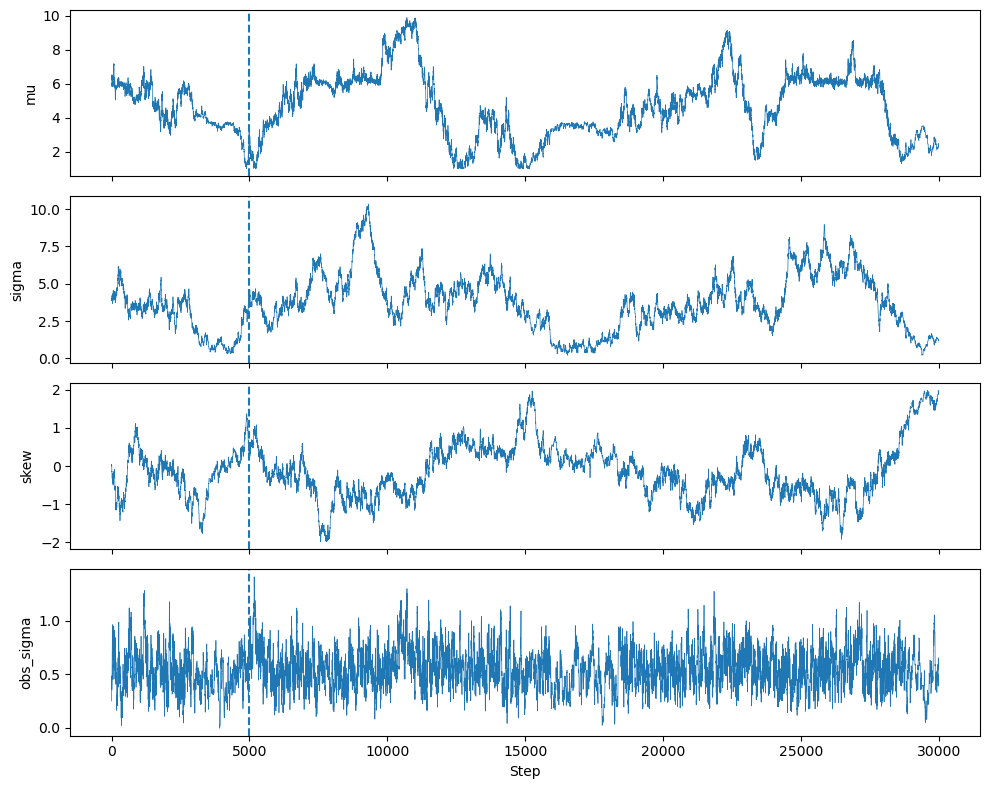

In [23]:
plot_chain(chain, burn=5000)

In [24]:
summary = summarise_posterior(chain, burn=5000, thin=10)

print("mu        :", summary["mu_mean"], "+/-", summary["mu_std"])
print("sigma     :", summary["sigma_mean"], "+/-", summary["sigma_std"])
print("skew      :", summary["skew_mean"], "+/-", summary["skew_std"])
print("obs_sigma :", summary["obs_sigma_mean"], "+/-", summary["obs_sigma_std"])

mu        : 4.696453836701586 +/- 1.972949808601778
sigma     : 3.9129466965327127 +/- 1.9206057248702342
skew      : -0.11900758642180713 +/- 0.7483693220936734
obs_sigma : 0.551141323486133 +/- 0.18364205954333207


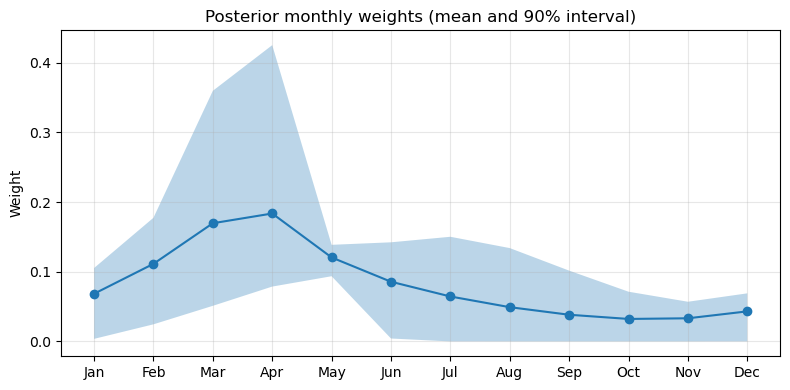

In [25]:
weight_samples = posterior_weight_samples(summary["samples"])
plot_posterior_weights(weight_samples)

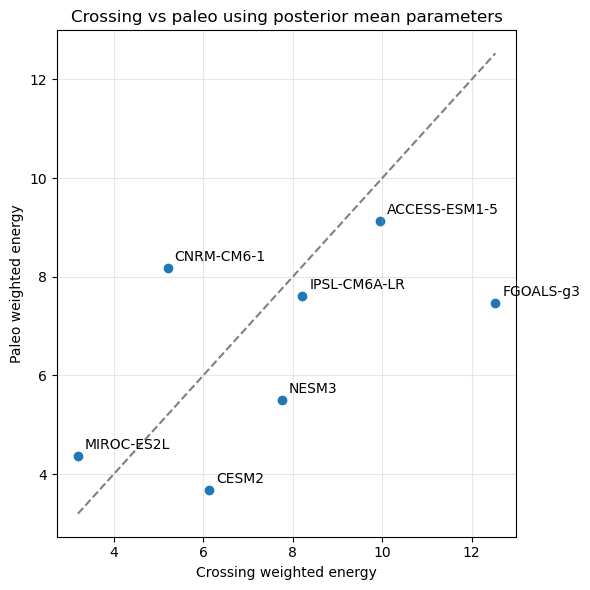

In [26]:
plot_posterior_crossing_vs_paleo(
    summary["samples"],
    models,
    crossing_big_dict,
    paleo_big_dict
)

In [27]:
burn = 5000
best_idx = np.argmax(logpost[burn:])
best_params = chain[burn:][best_idx]

mu_map, sigma_map, skew_map, log_obs_sigma_map = best_params
weights_map = skewed_gaussian_month_weights(mu_map, sigma_map, skew_map)

crossing_map, paleo_map, _ = calculate_model_energies(
    weights_map, models, crossing_big_dict, paleo_big_dict
)

rmse_map = np.sqrt(np.mean((crossing_map - paleo_map) ** 2))
print("MAP-like RMSE:", rmse_map)

MAP-like RMSE: 2.13418234265587


In [28]:
samples = chain[burn::10]

weight_samples = []
for mu, sigma, skew, log_obs_sigma in samples:
    w = skewed_gaussian_month_weights(mu, sigma, skew)
    if w is not None:
        weight_samples.append(w)

weight_samples = np.asarray(weight_samples)
weights_post_mean = weight_samples.mean(axis=0)

crossing_pm, paleo_pm, _ = calculate_model_energies(
    weights_post_mean, models, crossing_big_dict, paleo_big_dict
)

rmse_pm = np.sqrt(np.mean((crossing_pm - paleo_pm) ** 2))
print("Posterior-mean-weight RMSE:", rmse_pm)

Posterior-mean-weight RMSE: 2.2689531682912625


In [29]:
#EC-Earth3 failed to download, try new wget from a different location